In [1]:
# ============================================================
# Standalone ResUNet2D Quantitative Evaluation
#
# PT -> PA
#
# Metrics on DENORMALIZED PA:
#
#   MSE      ↓
#   MAE      ↓
#   RMSE     ↓
#   Rel. L2  ↓
#   R²       ↑
#
# ============================================================

import os
import glob
import csv
import random
import time

import numpy as np
import h5py

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm


# ============================================================
# 1. Configuration
# ============================================================

DATA_ROOT = r"Training dataset"


# ------------------------------------------------------------
# CHANGE THIS
#
# Example:
#
# RUN_DIR =
# r"resunet2d_mat_dataset_results/run_20260827_104848"
# ------------------------------------------------------------

RUN_DIR = r"resunet2d_mat_dataset_results/run_20260822_202413"


MODEL_PATH = os.path.join(
    RUN_DIR,
    "best_resunet2d.pt"
)


NORM_PATH = os.path.join(
    RUN_DIR,
    "normalization_parameters.npz"
)


SUMMARY_PATH = os.path.join(
    RUN_DIR,
    "quantitative_metrics.txt"
)


CSV_PATH = os.path.join(
    RUN_DIR,
    "per_sample_metrics.csv"
)


# ============================================================
# 2. Dataset configuration
# ============================================================

TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

SEED = 42


# ============================================================
# 3. ResUNet parameters
#
# MUST match training
# ============================================================

IN_CHANNELS = 1
OUT_CHANNELS = 1

BASE_CHANNELS = 32


# ============================================================
# 4. Data size
# ============================================================

NT = 501
NX = 200


# ============================================================
# Evaluation batch size
# ============================================================

BATCH_SIZE = 4


# ============================================================
# Device
# ============================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print("=" * 72)

print(
    "ResUNet2D QUANTITATIVE EVALUATION"
)

print("=" * 72)


print(
    "\nUsing device:",
    DEVICE
)


# ============================================================
# 5. Check files
# ============================================================

if not os.path.exists(
    MODEL_PATH
):

    raise FileNotFoundError(

        f"\nCannot find model:\n"
        f"{MODEL_PATH}\n\n"
        f"Please modify RUN_DIR."
    )


if not os.path.exists(
    NORM_PATH
):

    raise FileNotFoundError(

        f"\nCannot find normalization file:\n"
        f"{NORM_PATH}"
    )


print(
    "\nModel:"
)

print(
    MODEL_PATH
)


print(
    "\nNormalization:"
)

print(
    NORM_PATH
)


# ============================================================
# 6. Random seed
# ============================================================

random.seed(
    SEED
)

np.random.seed(
    SEED
)

torch.manual_seed(
    SEED
)


if torch.cuda.is_available():

    torch.cuda.manual_seed_all(
        SEED
    )


# ============================================================
# 7. Find dataset
# ============================================================

all_files = glob.glob(

    os.path.join(
        DATA_ROOT,
        "**",
        "*.mat"
    ),

    recursive=True
)


all_files = sorted(
    all_files
)


print(
    "\nTotal .mat samples found:",
    len(all_files)
)


if len(all_files) == 0:

    raise RuntimeError(

        f"No MAT files found under:\n"
        f"{DATA_ROOT}"
    )


# ============================================================
# 8. Reproduce exact train / val / test split
#
# Original training:
#
# random.seed(42)
# random.shuffle(all_files)
#
# ============================================================

random.shuffle(
    all_files
)


n_total = len(
    all_files
)


n_train = int(
    n_total
    *
    TRAIN_RATIO
)


n_val = int(
    n_total
    *
    VAL_RATIO
)


train_files = all_files[
    :n_train
]


val_files = all_files[
    n_train:
    n_train + n_val
]


test_files = all_files[
    n_train + n_val:
]


print(
    "\nDataset split:"
)


print(
    "Train:",
    len(train_files)
)


print(
    "Val  :",
    len(val_files)
)


print(
    "Test :",
    len(test_files)
)


# ============================================================
# 9. Load ORIGINAL normalization parameters
#
# Better than recomputing them:
# exactly the values used during training.
# ============================================================

norm = np.load(
    NORM_PATH
)


pt_mean = float(
    norm["pt_mean"]
)


pt_std = float(
    norm["pt_std"]
)


pa_mean = float(
    norm["pa_mean"]
)


pa_std = float(
    norm["pa_std"]
)


print(
    "\nNormalization parameters:"
)


print(
    f"PT mean = {pt_mean:.8e}"
)


print(
    f"PT std  = {pt_std:.8e}"
)


print(
    f"PA mean = {pa_mean:.8e}"
)


print(
    f"PA std  = {pa_std:.8e}"
)


# ============================================================
# 10. Dataset
# ============================================================

class MatHeatAcousticDataset(
    Dataset
):

    def __init__(
        self,
        file_list,
        pt_mean,
        pt_std,
        pa_mean,
        pa_std
    ):

        self.file_list = file_list

        self.pt_mean = pt_mean
        self.pt_std = pt_std

        self.pa_mean = pa_mean
        self.pa_std = pa_std


    def __len__(
        self
    ):

        return len(
            self.file_list
        )


    def __getitem__(
        self,
        idx
    ):

        mat_path = self.file_list[
            idx
        ]


        with h5py.File(
            mat_path,
            "r"
        ) as f:


            PT = np.asarray(

                f["PT"],

                dtype=np.float32
            )


            PA = np.asarray(

                f["PA"],

                dtype=np.float32
            )


        # ====================================================
        # Original ResUNet training expects:
        #
        # [501, 200]
        # ====================================================

        if PT.shape != (
            NT,
            NX
        ):

            raise ValueError(

                f"Wrong PT shape in:\n"
                f"{mat_path}\n"
                f"{PT.shape}"
            )


        if PA.shape != (
            NT,
            NX
        ):

            raise ValueError(

                f"Wrong PA shape in:\n"
                f"{mat_path}\n"
                f"{PA.shape}"
            )


        # ====================================================
        # Normalize
        # ====================================================

        PT = (

            PT
            -
            self.pt_mean

        ) / self.pt_std


        PA = (

            PA
            -
            self.pa_mean

        ) / self.pa_std


        # ====================================================
        # [T,X]
        #
        # ->
        #
        # [C,T,X]
        # ====================================================

        PT = torch.tensor(

            PT,

            dtype=torch.float32

        ).unsqueeze(
            0
        )


        PA = torch.tensor(

            PA,

            dtype=torch.float32

        ).unsqueeze(
            0
        )


        return (
            PT,
            PA,
            mat_path
        )


# ============================================================
# 11. Test dataset
# ============================================================

test_dataset = MatHeatAcousticDataset(

    test_files,

    pt_mean,
    pt_std,

    pa_mean,
    pa_std
)


test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=torch.cuda.is_available()
)


print(
    "\nTest loader ready."
)


# ============================================================
# 12. Residual Block
# ============================================================

class ResidualBlock(
    nn.Module
):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()


        self.conv1 = nn.Conv2d(

            in_channels,

            out_channels,

            kernel_size=3,

            padding=1,

            bias=False
        )


        self.bn1 = nn.BatchNorm2d(
            out_channels
        )


        self.conv2 = nn.Conv2d(

            out_channels,

            out_channels,

            kernel_size=3,

            padding=1,

            bias=False
        )


        self.bn2 = nn.BatchNorm2d(
            out_channels
        )


        # ====================================================
        # Residual shortcut
        # ====================================================

        if (
            in_channels
            !=
            out_channels
        ):

            self.shortcut = nn.Conv2d(

                in_channels,

                out_channels,

                kernel_size=1,

                bias=False
            )

        else:

            self.shortcut = (
                nn.Identity()
            )


    def forward(
        self,
        x
    ):

        residual = self.shortcut(
            x
        )


        x = self.conv1(
            x
        )


        x = self.bn1(
            x
        )


        x = F.gelu(
            x
        )


        x = self.conv2(
            x
        )


        x = self.bn2(
            x
        )


        x = (
            x
            +
            residual
        )


        x = F.gelu(
            x
        )


        return x


# ============================================================
# 13. Encoder / Down Block
# ============================================================

class DownBlock(
    nn.Module
):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()


        self.block = ResidualBlock(

            in_channels,

            out_channels
        )


        self.pool = nn.MaxPool2d(

            kernel_size=2,

            stride=2
        )


    def forward(
        self,
        x
    ):

        skip = self.block(
            x
        )


        x = self.pool(
            skip
        )


        return (
            x,
            skip
        )


# ============================================================
# 14. Decoder / Up Block
# ============================================================

class UpBlock(
    nn.Module
):

    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels
    ):

        super().__init__()


        self.reduce = nn.Conv2d(

            in_channels,

            out_channels,

            kernel_size=1
        )


        self.block = ResidualBlock(

            out_channels
            +
            skip_channels,

            out_channels
        )


    def forward(
        self,
        x,
        skip
    ):


        # ====================================================
        # Important:
        #
        # 501 is not divisible exactly by 2^4.
        #
        # Therefore resize to skip size.
        # ====================================================

        x = F.interpolate(

            x,

            size=skip.shape[-2:],

            mode="bilinear",

            align_corners=False
        )


        x = self.reduce(
            x
        )


        x = torch.cat(

            [
                x,
                skip
            ],

            dim=1
        )


        x = self.block(
            x
        )


        return x


# ============================================================
# 15. ResUNet2D
# ============================================================

class ResUNet2D(
    nn.Module
):

    def __init__(
        self,
        in_channels=1,
        out_channels=1,
        base_channels=32
    ):

        super().__init__()


        c1 = base_channels

        c2 = (
            base_channels
            *
            2
        )

        c3 = (
            base_channels
            *
            4
        )

        c4 = (
            base_channels
            *
            8
        )

        c5 = (
            base_channels
            *
            16
        )


        # ====================================================
        # Encoder
        # ====================================================

        self.down1 = DownBlock(
            in_channels,
            c1
        )


        self.down2 = DownBlock(
            c1,
            c2
        )


        self.down3 = DownBlock(
            c2,
            c3
        )


        self.down4 = DownBlock(
            c3,
            c4
        )


        # ====================================================
        # Bottleneck
        # ====================================================

        self.bottleneck = ResidualBlock(
            c4,
            c5
        )


        # ====================================================
        # Decoder
        # ====================================================

        self.up4 = UpBlock(
            c5,
            c4,
            c4
        )


        self.up3 = UpBlock(
            c4,
            c3,
            c3
        )


        self.up2 = UpBlock(
            c3,
            c2,
            c2
        )


        self.up1 = UpBlock(
            c2,
            c1,
            c1
        )


        # ====================================================
        # Output
        # ====================================================

        self.out_conv = nn.Conv2d(

            c1,

            out_channels,

            kernel_size=1
        )


    def forward(
        self,
        x
    ):


        input_size = x.shape[
            -2:
        ]


        # ====================================================
        # Encoder
        # ====================================================

        x, skip1 = self.down1(
            x
        )


        x, skip2 = self.down2(
            x
        )


        x, skip3 = self.down3(
            x
        )


        x, skip4 = self.down4(
            x
        )


        # ====================================================
        # Bottleneck
        # ====================================================

        x = self.bottleneck(
            x
        )


        # ====================================================
        # Decoder
        # ====================================================

        x = self.up4(
            x,
            skip4
        )


        x = self.up3(
            x,
            skip3
        )


        x = self.up2(
            x,
            skip2
        )


        x = self.up1(
            x,
            skip1
        )


        # ====================================================
        # Output
        # ====================================================

        x = self.out_conv(
            x
        )


        if (
            x.shape[-2:]
            !=
            input_size
        ):

            x = F.interpolate(

                x,

                size=input_size,

                mode="bilinear",

                align_corners=False
            )


        return x


# ============================================================
# 16. Build ResUNet
# ============================================================

resunet_model = ResUNet2D(

    in_channels=IN_CHANNELS,

    out_channels=OUT_CHANNELS,

    base_channels=BASE_CHANNELS

).to(
    DEVICE
)


# ============================================================
# 17. Load trained model
# ============================================================

print(
    "\nLoading trained ResUNet2D..."
)


state_dict = torch.load(

    MODEL_PATH,

    map_location=DEVICE,

    weights_only=True
)


resunet_model.load_state_dict(
    state_dict
)


resunet_model.eval()


print(
    "ResUNet2D loaded successfully."
)


# ============================================================
# 18. Global accumulators
# ============================================================

global_sse = 0.0

global_sae = 0.0

global_target_sq = 0.0

global_target_sum = 0.0

global_n = 0


per_sample_results = []


# ============================================================
# 19. Start testing
# ============================================================

print(
    "\nEvaluating test set..."
)


start_time = time.time()


sample_counter = 0


with torch.no_grad():


    for (

        PT_norm,

        PA_norm,

        file_paths

    ) in tqdm(

        test_loader,

        desc="Testing",

        ncols=100

    ):


        # ====================================================
        # Input to GPU
        # ====================================================

        PT_norm = PT_norm.to(

            DEVICE,

            non_blocking=True
        )


        # ====================================================
        # Prediction
        # ====================================================

        pred_norm = resunet_model(
            PT_norm
        )


        # ====================================================
        # CPU
        # ====================================================

        pred_norm = (

            pred_norm
            .detach()
            .cpu()
            .numpy()
        )


        PA_norm_np = (
            PA_norm.numpy()
        )


        # ====================================================
        # DENORMALIZATION
        #
        # All metrics below are calculated
        # in ORIGINAL PA scale.
        # ====================================================

        pred_real = (

            pred_norm
            *
            pa_std
            +
            pa_mean
        )


        PA_real = (

            PA_norm_np
            *
            pa_std
            +
            pa_mean
        )


        current_batch_size = (
            pred_real.shape[0]
        )


        # ====================================================
        # Per sample
        # ====================================================

        for j in range(
            current_batch_size
        ):


            sample_counter += 1


            pred_j = (

                pred_real[j]

                .reshape(-1)

                .astype(
                    np.float64
                )
            )


            true_j = (

                PA_real[j]

                .reshape(-1)

                .astype(
                    np.float64
                )
            )


            error_j = (
                pred_j
                -
                true_j
            )


            # =================================================
            # MSE
            # =================================================

            mse_j = np.mean(
                error_j ** 2
            )


            # =================================================
            # MAE
            # =================================================

            mae_j = np.mean(

                np.abs(
                    error_j
                )
            )


            # =================================================
            # RMSE
            # =================================================

            rmse_j = np.sqrt(
                mse_j
            )


            # =================================================
            # Relative L2
            # =================================================

            rel_l2_j = (

                np.linalg.norm(
                    error_j
                )

                /

                (
                    np.linalg.norm(
                        true_j
                    )

                    +
                    1e-12
                )
            )


            # =================================================
            # R²
            # =================================================

            ss_res_j = np.sum(
                error_j ** 2
            )


            true_mean_j = np.mean(
                true_j
            )


            ss_tot_j = np.sum(

                (
                    true_j
                    -
                    true_mean_j
                )

                ** 2
            )


            r2_j = (

                1.0

                -

                ss_res_j

                /

                (
                    ss_tot_j
                    +
                    1e-12
                )
            )


            # =================================================
            # Save sample
            # =================================================

            per_sample_results.append(

                [
                    sample_counter,
                    file_paths[j],
                    mse_j,
                    mae_j,
                    rmse_j,
                    rel_l2_j,
                    r2_j
                ]
            )


            # =================================================
            # Global accumulators
            # =================================================

            global_sse += np.sum(
                error_j ** 2
            )


            global_sae += np.sum(

                np.abs(
                    error_j
                )
            )


            global_target_sq += np.sum(
                true_j ** 2
            )


            global_target_sum += np.sum(
                true_j
            )


            global_n += true_j.size


# ============================================================
# 20. Global MSE
# ============================================================

global_mse = (

    global_sse

    /

    global_n
)


# ============================================================
# 21. Global MAE
# ============================================================

global_mae = (

    global_sae

    /

    global_n
)


# ============================================================
# 22. Global RMSE
# ============================================================

global_rmse = np.sqrt(
    global_mse
)


# ============================================================
# 23. Global Relative L2
#
# sqrt(SSE) / sqrt(sum(y^2))
# ============================================================

global_rel_l2 = (

    np.sqrt(
        global_sse
    )

    /

    (
        np.sqrt(
            global_target_sq
        )

        +
        1e-12
    )
)


# ============================================================
# 24. Global R²
#
# SST = sum(y²) - sum(y)²/N
# ============================================================

global_sst = (

    global_target_sq

    -

    (
        global_target_sum ** 2

        /

        global_n
    )
)


global_r2 = (

    1.0

    -

    global_sse

    /

    (
        global_sst
        +
        1e-12
    )
)


# ============================================================
# 25. Per-sample mean ± std
# ============================================================

metric_array = np.asarray(

    [
        row[2:]
        for row in per_sample_results
    ],

    dtype=np.float64
)


sample_mean = np.mean(
    metric_array,
    axis=0
)


sample_std = np.std(
    metric_array,
    axis=0
)


# ============================================================
# 26. Timing
# ============================================================

elapsed_time = (

    time.time()
    -
    start_time
)


time_per_sample = (

    elapsed_time

    /

    len(
        test_dataset
    )
)


# ============================================================
# 27. Print final results
# ============================================================

print("\n")

print("=" * 74)

print(
    "ResUNet2D FINAL QUANTITATIVE RESULTS"
)

print(
    "Metrics calculated on DENORMALIZED PA"
)

print("=" * 74)


print(
    f"MSE      : "
    f"{global_mse:.8e}"
)


print(
    f"MAE      : "
    f"{global_mae:.8e}"
)


print(
    f"RMSE     : "
    f"{global_rmse:.8e}"
)


print(
    f"Rel. L2  : "
    f"{global_rel_l2:.8e}"
)


print(
    f"R²       : "
    f"{global_r2:.8f}"
)


print("-" * 74)


print(
    "Per-sample mean ± std:"
)


print(
    f"MSE      : "
    f"{sample_mean[0]:.8e} "
    f"± {sample_std[0]:.8e}"
)


print(
    f"MAE      : "
    f"{sample_mean[1]:.8e} "
    f"± {sample_std[1]:.8e}"
)


print(
    f"RMSE     : "
    f"{sample_mean[2]:.8e} "
    f"± {sample_std[2]:.8e}"
)


print(
    f"Rel. L2  : "
    f"{sample_mean[3]:.8e} "
    f"± {sample_std[3]:.8e}"
)


print(
    f"R²       : "
    f"{sample_mean[4]:.8f} "
    f"± {sample_std[4]:.8f}"
)


print("-" * 74)


print(
    f"Evaluation time : "
    f"{elapsed_time:.2f} s"
)


print(
    f"Time/sample     : "
    f"{time_per_sample:.4f} s"
)


print("=" * 74)


# ============================================================
# 28. Save per-sample CSV
# ============================================================

with open(

    CSV_PATH,

    "w",

    newline=""

) as f:


    writer = csv.writer(
        f
    )


    writer.writerow(

        [
            "sample",
            "file",
            "mse",
            "mae",
            "rmse",
            "relative_l2",
            "r2"
        ]
    )


    writer.writerows(
        per_sample_results
    )


# ============================================================
# 29. Save summary TXT
# ============================================================

with open(

    SUMMARY_PATH,

    "w"

) as f:


    f.write(
        "ResUNet2D Quantitative Evaluation\n"
    )


    f.write(
        "Metrics calculated on "
        "DENORMALIZED PA\n\n"
    )


    f.write(
        "Global test-set metrics\n"
    )


    f.write(
        "=======================\n"
    )


    f.write(
        f"MSE      : "
        f"{global_mse:.8e}\n"
    )


    f.write(
        f"MAE      : "
        f"{global_mae:.8e}\n"
    )


    f.write(
        f"RMSE     : "
        f"{global_rmse:.8e}\n"
    )


    f.write(
        f"Rel. L2  : "
        f"{global_rel_l2:.8e}\n"
    )


    f.write(
        f"R2       : "
        f"{global_r2:.8f}\n"
    )


    f.write(
        "\nPer-sample mean +/- std\n"
    )


    f.write(
        "========================\n"
    )


    names = [
        "MSE",
        "MAE",
        "RMSE",
        "Rel. L2",
        "R2"
    ]


    for (
        name,
        mean,
        std
    ) in zip(
        names,
        sample_mean,
        sample_std
    ):


        f.write(

            f"{name:<8}: "

            f"{mean:.8e} "

            f"+/- "

            f"{std:.8e}\n"
        )


    f.write(
        "\nTiming\n"
    )


    f.write(
        "======\n"
    )


    f.write(

        f"Total evaluation time : "
        f"{elapsed_time:.4f} s\n"
    )


    f.write(

        f"Time per sample       : "
        f"{time_per_sample:.6f} s\n"
    )


# ============================================================
# 30. Finish
# ============================================================

print(
    "\nResults saved to:"
)


print(
    SUMMARY_PATH
)


print(
    CSV_PATH
)


print(
    "\nResUNet2D quantitative evaluation complete."
)

ResUNet2D QUANTITATIVE EVALUATION

Using device: cuda

Model:
resunet2d_mat_dataset_results/run_20260822_202413/best_resunet2d.pt

Normalization:
resunet2d_mat_dataset_results/run_20260822_202413/normalization_parameters.npz

Total .mat samples found: 800

Dataset split:
Train: 640
Val  : 80
Test : 80

Normalization parameters:
PT mean = 3.13556727e+01
PT std  = 2.16473979e+01
PA mean = -2.10088660e+04
PA std  = 2.84782403e+05

Test loader ready.

Loading trained ResUNet2D...
ResUNet2D loaded successfully.

Evaluating test set...


Testing:   0%|                                                               | 0/20 [00:00<?, ?it/s]



ResUNet2D FINAL QUANTITATIVE RESULTS
Metrics calculated on DENORMALIZED PA
MSE      : 3.02795271e+10
MAE      : 4.43281641e+04
RMSE     : 1.74010135e+05
Rel. L2  : 5.28326296e-01
R²       : 0.71862075
--------------------------------------------------------------------------
Per-sample mean ± std:
MSE      : 3.02795271e+10 ± 7.94483168e+10
MAE      : 4.43281641e+04 ± 7.34291539e+04
RMSE     : 9.04800051e+04 ± 1.48636791e+05
Rel. L2  : 6.81669039e-01 ± 2.53936624e-01
R²       : 0.45747920 ± 0.39902454
--------------------------------------------------------------------------
Evaluation time : 14.83 s
Time/sample     : 0.1854 s

Results saved to:
resunet2d_mat_dataset_results/run_20260822_202413/quantitative_metrics.txt
resunet2d_mat_dataset_results/run_20260822_202413/per_sample_metrics.csv

ResUNet2D quantitative evaluation complete.


PT shape: (501, 200)
PA ground-truth shape: (501, 200)
Network input shape: torch.Size([1, 1, 501, 200])
Predicted PA shape: (501, 200)


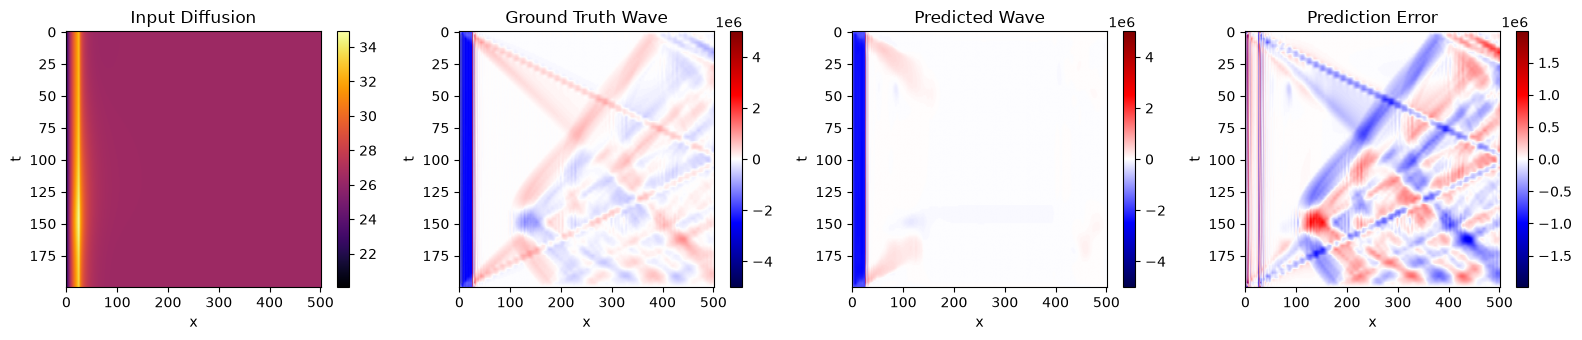

Figure saved to: resunet2d_mat_dataset_results/run_20260822_202413/visualization_prediction/prediction_comparison.png


In [7]:
import os
import glob
import random
import numpy as np
import h5py
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================================
# Visualization prediction
# ============================================================

PREDICT_FILE = os.path.join(
    DATA_ROOT,
    "1",
    "Irregular_3_PT_0.5.mat"
)


OUT_DIR_VIS = os.path.join(
    RUN_DIR,
    "visualization_prediction"
)

os.makedirs(
    OUT_DIR_VIS,
    exist_ok=True
)


# ============================================================
# Load prediction sample
# ============================================================

def load_prediction_sample(mat_path):

    assert os.path.isfile(mat_path), (
        f"Prediction file not found: {mat_path}"
    )

    with h5py.File(
        mat_path,
        "r"
    ) as f:

        PT = np.asarray(
            f["PT"],
            dtype=np.float32
        )

        if "PA" in f:

            PA = np.asarray(
                f["PA"],
                dtype=np.float32
            )

        else:

            PA = None


    assert PT.shape == (
        NT,
        NX
    ), (
        f"Wrong PT shape: {PT.shape}"
    )


    if PA is not None:

        assert PA.shape == (
            NT,
            NX
        ), (
            f"Wrong PA shape: {PA.shape}"
        )


    return PT, PA


# ============================================================
# Load data
# ============================================================

PT_real, PA_real = load_prediction_sample(
    PREDICT_FILE
)


print(
    "PT shape:",
    PT_real.shape
)


if PA_real is not None:

    print(
        "PA ground-truth shape:",
        PA_real.shape
    )

else:

    print(
        "No PA ground truth found in this file."
    )


# ============================================================
# Normalize input
# ============================================================

PT_norm = (

    PT_real
    -
    pt_mean

) / pt_std


PT_tensor = torch.tensor(

    PT_norm,

    dtype=torch.float32

).unsqueeze(
    0

).unsqueeze(
    0

).to(
    DEVICE
)


print(
    "Network input shape:",
    PT_tensor.shape
)


# ============================================================
# Prediction
# ============================================================

resunet_model.eval()


with torch.no_grad():

    PA_pred_norm = resunet_model(
        PT_tensor
    )


PA_pred_norm = (

    PA_pred_norm
    .cpu()
    .squeeze(0)
    .squeeze(0)
    .numpy()
)


# ============================================================
# Denormalize predicted PA
# ============================================================

PA_pred = (

    PA_pred_norm
    *
    pa_std
    +
    pa_mean
)


print(
    "Predicted PA shape:",
    PA_pred.shape
)


# ============================================================
# Visualization
# ============================================================

if PA_real is not None:


    error = (

        PA_pred
        -
        PA_real
    )


    # --------------------------------------------------------
    # Transpose for visualization
    #
    # [501, 200] -> [200, 501]
    # --------------------------------------------------------

    PT_plot = PT_real.T

    PA_real_plot = PA_real.T

    PA_pred_plot = PA_pred.T

    error_plot = error.T


    vmax = max(

        np.max(
            np.abs(
                PA_real_plot
            )
        ),

        np.max(
            np.abs(
                PA_pred_plot
            )
        )
    )


    evmax = np.max(
        np.abs(
            error_plot
        )
    )


    fig, axes = plt.subplots(

        1,

        4,

        figsize=(
            16,
            3.5
        )
    )


    # --------------------------------------------------------
    # Input PT
    # --------------------------------------------------------

    im0 = axes[0].imshow(

        PT_plot,

        aspect="auto",

        cmap="inferno"
    )


    axes[0].set_title(
        "Input Diffusion"
    )

    axes[0].set_xlabel(
        "x"
    )

    axes[0].set_ylabel(
        "t"
    )


    fig.colorbar(
        im0,
        ax=axes[0]
    )


    # --------------------------------------------------------
    # Ground truth PA
    # --------------------------------------------------------

    im1 = axes[1].imshow(

        PA_real_plot,

        aspect="auto",

        cmap="seismic",

        vmin=-vmax,

        vmax=vmax
    )


    axes[1].set_title(
        "Ground Truth Wave"
    )

    axes[1].set_xlabel(
        "x"
    )

    axes[1].set_ylabel(
        "t"
    )


    fig.colorbar(
        im1,
        ax=axes[1]
    )


    # --------------------------------------------------------
    # Predicted PA
    # --------------------------------------------------------

    im2 = axes[2].imshow(

        PA_pred_plot,

        aspect="auto",

        cmap="seismic",

        vmin=-vmax,

        vmax=vmax
    )


    axes[2].set_title(
        "Predicted Wave"
    )

    axes[2].set_xlabel(
        "x"
    )

    axes[2].set_ylabel(
        "t"
    )


    fig.colorbar(
        im2,
        ax=axes[2]
    )


    # --------------------------------------------------------
    # Error
    # --------------------------------------------------------

    im3 = axes[3].imshow(

        error_plot,

        aspect="auto",

        cmap="seismic",

        vmin=-evmax,

        vmax=evmax
    )


    axes[3].set_title(
        "Prediction Error"
    )

    axes[3].set_xlabel(
        "x"
    )

    axes[3].set_ylabel(
        "t"
    )


    fig.colorbar(
        im3,
        ax=axes[3]
    )


    plt.tight_layout()


else:


    PT_plot = PT_real.T

    PA_pred_plot = PA_pred.T


    fig, axes = plt.subplots(

        1,

        2,

        figsize=(
            9,
            3.5
        )
    )


    im0 = axes[0].imshow(

        PT_plot,

        aspect="auto",

        cmap="inferno"
    )


    axes[0].set_title(
        "Input Diffusion"
    )

    axes[0].set_xlabel(
        "x"
    )

    axes[0].set_ylabel(
        "t"
    )


    fig.colorbar(
        im0,
        ax=axes[0]
    )


    vmax = np.max(
        np.abs(
            PA_pred_plot
        )
    )


    im1 = axes[1].imshow(

        PA_pred_plot,

        aspect="auto",

        cmap="seismic",

        vmin=-vmax,

        vmax=vmax
    )


    axes[1].set_title(
        "Predicted Wave"
    )

    axes[1].set_xlabel(
        "x"
    )

    axes[1].set_ylabel(
        "t"
    )


    fig.colorbar(
        im1,
        ax=axes[1]
    )


    plt.tight_layout()


# ============================================================
# Save figure
# ============================================================

plot_path = os.path.join(

    OUT_DIR_VIS,

    "prediction_comparison.png"
)


plt.savefig(

    plot_path,

    dpi=300,

    bbox_inches="tight"
)


plt.show()


print(
    "Figure saved to:",
    plot_path
)